 Fetch live cricket match data
● Analyze player performance
● Track team statistics
● Visualize match summaries
● Generate score reports
● Compare teams and players

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import requests


API_KEY = "2aa0ed5c-67cb-47c0-b812-87d72b8744e7"

url = f"https://api.cricapi.com/v1/currentMatches?apikey={API_KEY}&offset=0"

response = requests.get(url)

data = response.json()

if data["status"] != "success":
    print("Error:", data["reason"])
    exit()

matches = data["data"]
print(matches)

[{'id': 'f10f3998-db68-46b1-b603-2c48fbc7a0d1', 'name': 'Sri Lanka U19 vs India U19, 1st unofficial Test, India U19 tour of Sri Lanka 2026', 'status': 'Day 4: 3rd Session - Sri Lanka U19 trail by 127 runs', 'venue': 'Galle International Stadium, Galle', 'date': '2026-07-13', 'dateTimeGMT': '2026-07-13T04:00:00', 'teams': ['Sri Lanka U19', 'India U19'], 'teamInfo': [{'name': 'India U19', 'shortname': 'IN19', 'img': 'https://g.cricapi.com/iapi/32-637877061328728555.webp?w=48'}, {'name': 'Sri Lanka U19', 'shortname': 'SL19', 'img': 'https://h.cricapi.com/img/icon512.png'}], 'score': [{'r': 424, 'w': 9, 'o': 106.4, 'inning': 'sri lanka u19 Inning 1'}, {'r': 576, 'w': 10, 'o': 173.5, 'inning': 'Sri Lanka U19,India U19 Inning 1'}, {'r': 25, 'w': 1, 'o': 6.5, 'inning': 'sri lanka u19 Inning 2'}], 'series_id': '614d9bda-b605-4034-8878-f67a9e0ed614', 'fantasyEnabled': True, 'bbbEnabled': False, 'hasSquad': False, 'matchStarted': True, 'matchEnded': False}]


In [2]:

match_list = []

for match in matches:
    team1 = match.get("teams", ["",""])[0]
    team2 = match.get("teams", ["",""])[1]

    score = ""

    if match.get("score"):
        score = " | ".join(
            [f"{s['inning']} : {s['r']}/{s['w']} ({s['o']} ov)"
             for s in match["score"]]
        )

    match_list.append({
        "Match": f"{team1} vs {team2}",
        "Status": match.get("status"),
        "Venue": match.get("venue"),
        "Score": score
    })

df = pd.DataFrame(match_list)

print(df.to_string())


                        Match                                                Status                               Venue                                                                                                                                      Score
0  Sri Lanka U19 vs India U19  Day 4: 3rd Session - Sri Lanka U19 trail by 127 runs  Galle International Stadium, Galle  sri lanka u19 Inning 1 : 424/9 (106.4 ov) | Sri Lanka U19,India U19 Inning 1 : 576/10 (173.5 ov) | sri lanka u19 Inning 2 : 25/1 (6.5 ov)


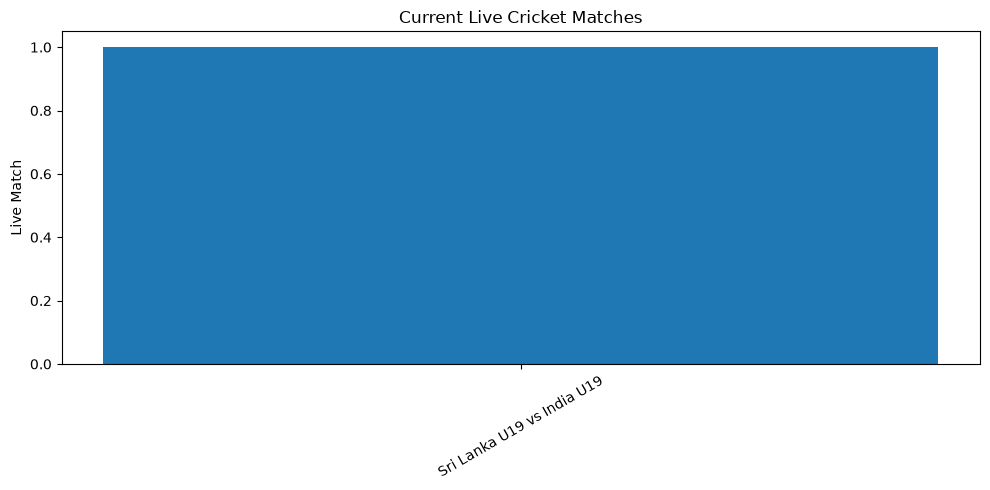

In [3]:

# Save Report
df.to_csv("Cricket_Report.csv", index=False)

# Visualization
plt.figure(figsize=(10,5))
plt.bar(df["Match"], [1]*len(df))
plt.xticks(rotation=30)
plt.ylabel("Live Match")
plt.title("Current Live Cricket Matches")
plt.tight_layout()
plt.show()

In [4]:
url = f"https://api.cricapi.com/v1/currentMatches?apikey={API_KEY}&offset=0"

response = requests.get(url)

data = response.json()

for match in data["data"]:
    print(match["id"])
    print(match["name"])
    print()

f10f3998-db68-46b1-b603-2c48fbc7a0d1
Sri Lanka U19 vs India U19, 1st unofficial Test, India U19 tour of Sri Lanka 2026



In [5]:
MATCH_ID = "3d719cf3-7cec-413e-b753-2b5c719d0d11"

url = f"https://api.cricapi.com/v1/match_scorecard?apikey={API_KEY}&id={MATCH_ID}"

response = requests.get(url)

print(response.json())

{'apikey': '2aa0ed5c-67cb-47c0-b812-87d72b8744e7', 'data': {'id': '3d719cf3-7cec-413e-b753-2b5c719d0d11', 'name': 'Ranga Reddy Risers vs Warangal Warriors, 28th Match, TG20 2026', 'matchType': 't20', 'status': 'Ranga Reddy Risers won by 161 runs', 'venue': 'Rajiv Gandhi International Stadium, Hyderabad', 'date': '2026-07-07', 'dateTimeGMT': '2026-07-07T13:45:00', 'teams': ['Ranga Reddy Risers', 'Warangal Warriors'], 'teamInfo': [{'name': 'Ranga Reddy Risers', 'img': 'https://h.cricapi.com/img/icon512.png'}, {'name': 'Warangal Warriors', 'img': 'https://h.cricapi.com/img/icon512.png'}], 'score': [{'r': 252, 'w': 6, 'o': 20, 'inning': 'ranga reddy risers Inning 1'}, {'r': 91, 'w': 10, 'o': 12.3, 'inning': 'Ranga Reddy Risers,Warangal Warriors Inning 1'}], 'tossWinner': 'ranga reddy risers', 'tossChoice': 'bat', 'matchWinner': 'Ranga Reddy Risers', 'series_id': '74597738-d75d-43b5-8aff-ed79811e42fa', 'scorecard': [{'batting': [{'batsman': {'id': 'd5229540-871b-4924-b054-65a98a971515', 'na

In [6]:
url = f"https://api.cricapi.com/v1/currentMatches?apikey={API_KEY}&offset=0"

response = requests.get(url)
data = response.json()

# Select the first match
match = data["data"][0]

total_runs = 0

for innings in match["score"]:
    total_runs += innings["r"]

print("Match:", match["name"])
print("Total Runs:", total_runs)

Match: Sri Lanka U19 vs India U19, 1st unofficial Test, India U19 tour of Sri Lanka 2026
Total Runs: 1025


In [7]:
match = data["data"][0]

scores = match["score"]

for innings in scores:
    print(
        innings["inning"],
        "- Runs:", innings["r"],
        "Wickets:", innings["w"],
        "Overs:", innings["o"]
    )

sri lanka u19 Inning 1 - Runs: 424 Wickets: 9 Overs: 106.4
Sri Lanka U19,India U19 Inning 1 - Runs: 576 Wickets: 10 Overs: 173.5
sri lanka u19 Inning 2 - Runs: 25 Wickets: 1 Overs: 6.5


In [8]:
with open("Score_Report.txt", "w") as file:
    file.write(df.to_string(index=False))

print("Report Generated")

Report Generated


In [9]:
url="https://api.cricapi.com/v1/series?apikey=2aa0ed5c-67cb-47c0-b812-87d72b8744e7&offset=0&search="

myrequest=requests.get(url)
data=myrequest.json()

matches1 = data["data"]
print(matches1)


[{'id': 'c58c8862-0d1d-413a-88a5-bc84b11e3211', 'name': 'Australia Women tour of South Africa, 2027', 'startDate': '2027-03-18', 'endDate': 'Apr 11', 'odi': 3, 't20': 3, 'test': 1, 'squads': 0, 'matches': 7}, {'id': 'eb59e02f-5f61-40c9-9f88-5824445e62b5', 'name': 'Australia vs England, 150th Anniversary One-off Test Match, 2027', 'startDate': '2027-03-11', 'endDate': 'Mar 15', 'odi': 0, 't20': 0, 'test': 1, 'squads': 0, 'matches': 1}, {'id': 'f3a3b820-9aa0-4816-857b-27470804d557', 'name': 'New Zealand Women tour of Australia, 2027', 'startDate': '2027-03-06', 'endDate': 'Mar 11', 'odi': 3, 't20': 0, 'test': 0, 'squads': 0, 'matches': 3}, {'id': '6489ceaf-6b96-426f-8092-4d47d0b34d9b', 'name': 'New Zealand Women tour of Australia, 2026', 'startDate': 'Oct 18', 'endDate': 'Oct 22', 'odi': 0, 't20': 3, 'test': 0, 'squads': 0, 'matches': 0}, {'id': '181dfb42-895f-4a4d-8907-94c125df9871', 'name': 'Australia tour of India, 2027', 'startDate': '2027-01-21', 'endDate': 'Mar 03', 'odi': 0, 't20'

In [10]:
match_list = []

for match in matches1:
    match_list.append({
        "id":match.get("id"),
        "name":match.get("name"),
        "startDate":match.get("startDate"),
        "endDate":match.get("endDate"),
        "odi":match.get("odi"),
        "t20":match.get("t20"),
        "test":match.get("test"),
        "squads":match.get("squads"),
        "matches":match.get("matches")
        
    })

df = pd.DataFrame(match_list)

print(df.to_string())



                                      id                                                              name   startDate endDate  odi  t20  test  squads  matches
0   c58c8862-0d1d-413a-88a5-bc84b11e3211                        Australia Women tour of South Africa, 2027  2027-03-18  Apr 11    3    3     1       0        7
1   eb59e02f-5f61-40c9-9f88-5824445e62b5  Australia vs England, 150th Anniversary One-off Test Match, 2027  2027-03-11  Mar 15    0    0     1       0        1
2   f3a3b820-9aa0-4816-857b-27470804d557                         New Zealand Women tour of Australia, 2027  2027-03-06  Mar 11    3    0     0       0        3
3   6489ceaf-6b96-426f-8092-4d47d0b34d9b                         New Zealand Women tour of Australia, 2026      Oct 18  Oct 22    0    3     0       0        0
4   181dfb42-895f-4a4d-8907-94c125df9871                                     Australia tour of India, 2027  2027-01-21  Mar 03    0    0     5       0        5
5   d8ce235b-bf83-423d-8ac3-764b94cb607c

In [11]:
df=df.drop("squads",axis=1)
print(df.to_string())

                                      id                                                              name   startDate endDate  odi  t20  test  matches
0   c58c8862-0d1d-413a-88a5-bc84b11e3211                        Australia Women tour of South Africa, 2027  2027-03-18  Apr 11    3    3     1        7
1   eb59e02f-5f61-40c9-9f88-5824445e62b5  Australia vs England, 150th Anniversary One-off Test Match, 2027  2027-03-11  Mar 15    0    0     1        1
2   f3a3b820-9aa0-4816-857b-27470804d557                         New Zealand Women tour of Australia, 2027  2027-03-06  Mar 11    3    0     0        3
3   6489ceaf-6b96-426f-8092-4d47d0b34d9b                         New Zealand Women tour of Australia, 2026      Oct 18  Oct 22    0    3     0        0
4   181dfb42-895f-4a4d-8907-94c125df9871                                     Australia tour of India, 2027  2027-01-21  Mar 03    0    0     5        5
5   d8ce235b-bf83-423d-8ac3-764b94cb607c                                   Sri Lanka tou

In [13]:
print(df.columns)

Index(['id', 'name', 'startDate', 'endDate', 'odi', 't20', 'test', 'matches'], dtype='str')


In [15]:
df.corr(numeric_only=True)


,odi,t20,test,matches
odi,1.000000,-0.101325,-0.071246,0.516362
t20,-0.101325,1.000000,-0.084612,0.501955
test,-0.071246,-0.084612,1.000000,0.527929
matches,0.516362,0.501955,0.527929,1.000000


In [16]:
print(df.describe(include='object'))

                                          id  \
count                                     25   
unique                                    25   
top     c58c8862-0d1d-413a-88a5-bc84b11e3211   
freq                                       1   

                                             name   startDate endDate  
count                                          25          25      25  
unique                                         24          22      20  
top     New Zealand Women tour of Australia, 2026  2026-12-14  Oct 22  
freq                                            2           2       2  


C:\Users\Hardik\AppData\Local\Temp\ipykernel_2160\3781773561.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))
